# StochastiQ — Notebook 03: Stochastic Model Calibration

**Project:** StochastiQ — Multi-model portfolio optimization and derivatives strategy framework  
**Course:** MGT 6081 Derivative Securities, Georgia Institute of Technology  
**Author:** Anay Abhijit Joshi

---

## Objectives

Calibrate four stochastic models to each of the seven assets in the universe — **28 calibrations in total** — using documented, defensible procedures. For each calibration we record the full parameter set, validate the result, and produce diagnostic plots that show how well each model captures the empirical return distribution.

## Models and Calibration Procedures

| Model | Procedure | Output Parameters |
|-------|-----------|-------------------|
| **GBM** | Maximum likelihood on log returns | $\mu$, $\sigma$ |
| **Merton** | Threshold method ($3\sigma$ jumps), then re-estimate diffusion on cleaned returns | $\mu$, $\sigma$, $\lambda_J$, $\mu_J$, $\sigma_J$ |
| **CEV** | OLS regression of $\log\|\Delta S\|$ on $\log S$ | $\mu$, $\sigma$, $\gamma$ |
| **Heston** | Method of moments on rolling 21-day realized variance | $\mu$, $\kappa$, $\theta$, $\sigma_v$, $\rho$, $v_0$ |

## Critical Validation

For Heston, we explicitly verify the **Feller condition** $2\kappa\theta > \sigma_v^2$, which guarantees that the variance process remains strictly positive. Violation of this condition does not invalidate the calibration but indicates the model can produce zero-variance regimes; we flag any such cases.

We also produce **Q-Q plots** comparing each model's simulated return distribution against the empirical distribution. This is the single most informative diagnostic: it shows visually which model captures each asset's tail behavior best — exactly the information needed to answer the project's "which model is most pertaining" question.

## 1. Setup

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from src.config import RISK_FREE_RATE, TRADING_DAYS, RANDOM_SEED
from src.data.loaders import load_dataset
from src.models.gbm import GBMParams, simulate_gbm
from src.models.merton import MertonParams, simulate_merton
from src.models.cev import CEVParams, simulate_cev
from src.models.heston import HestonParams, simulate_heston
from src.calibration.calibrators import (
    calibrate_gbm,
    calibrate_merton,
    calibrate_cev,
    calibrate_heston,
    calibrate_all_models,
)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["savefig.dpi"] = 150

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root:  {PROJECT_ROOT}")
print(f"Trading days:  {TRADING_DAYS}")
print(f"Random seed:   {RANDOM_SEED}")

Project root:  /Users/anayjoshi/Downloads/StochastiQ
Trading days:  252
Random seed:   42


## 2. Load Data

In [2]:
prices = load_dataset(PROCESSED_DIR / "prices.parquet")
log_returns = load_dataset(PROCESSED_DIR / "log_returns.parquet")
tickers = list(log_returns.columns)

print(f"Date range: {log_returns.index.min().date()} to {log_returns.index.max().date()}")
print(f"Trading days: {len(log_returns)}")
print(f"Assets ({len(tickers)}): {tickers}")

Date range: 2020-01-03 to 2026-04-30
Trading days: 1589
Assets (7): ['AAPL', 'MSFT', 'JPM', 'JNJ', 'XOM', 'SPY', 'GLD']


## 3. Calibrate All Models for All Assets

We run the full grid of 28 calibrations. Each model is fitted independently per asset, with no parameter sharing across assets.

In [3]:
# Nested dict: calibrated[ticker][model_name] -> Params
calibrated = {}

for ticker in tickers:
    calibrated[ticker] = calibrate_all_models(
        prices[ticker],
        log_returns[ticker],
        trading_days=TRADING_DAYS,
    )

print("All 28 calibrations complete.\n")

# Quick summary print
for ticker in tickers:
    print(f"{ticker}:")
    for model_name, params in calibrated[ticker].items():
        print(f"  {model_name}: {params}")

All 28 calibrations complete.

AAPL:
  GBM: GBMParams(mu=np.float64(0.25885440542501326), sigma=np.float64(0.3140876263931633))
  Merton: MertonParams(mu=0.2626761446170584, sigma=0.26752348909875523, lambda_j=3.647577092511013, mu_j=0.011655056019897784, sigma_j=0.0890502973512063)
  CEV: CEVParams(mu=0.25885440542501326, sigma=0.3140876263931633, gamma=1.0)
  Heston: HestonParams(mu=0.25921773606369086, kappa=2.6382391997646666, theta=0.09937769833064654, sigma_v=0.9581505183994912, rho=0.010443577039308118, v0=0.05499380609141258)
MSFT:
  GBM: GBMParams(mu=np.float64(0.20070387057483602), sigma=np.float64(0.2978744907278544))
  Merton: MertonParams(mu=0.2037342643307005, sigma=0.2519241570240071, lambda_j=3.8061674008810575, mu_j=0.009952396060083009, sigma_j=0.08421555046867388)
  CEV: CEVParams(mu=0.20070387057483602, sigma=0.2978744907278544, gamma=1.0)
  Heston: HestonParams(mu=0.2007523857669484, kappa=2.431805236837323, theta=0.08882624261060336, sigma_v=0.9786396476018578, rh

## 4. Parameter Comparison Tables

We present the calibrated parameters in a series of tables, one per model. This is the primary reference output for the writeup.

### 4.1 GBM Parameters

In [4]:
gbm_table = pd.DataFrame({
    ticker: {
        "mu (annual)":    calibrated[ticker]["GBM"].mu,
        "sigma (annual)": calibrated[ticker]["GBM"].sigma,
    }
    for ticker in tickers
}).T

gbm_table.style.format({
    "mu (annual)":    "{:.2%}",
    "sigma (annual)": "{:.2%}",
}).background_gradient(cmap="YlOrRd", subset=["sigma (annual)"])

,mu (annual),sigma (annual)
AAPL,25.89%,31.41%
MSFT,20.07%,29.79%
JPM,20.24%,31.02%
JNJ,11.86%,19.49%
XOM,22.20%,32.67%
SPY,16.12%,20.50%
GLD,18.76%,18.11%


### 4.2 Merton Jump-Diffusion Parameters

In [5]:
merton_table = pd.DataFrame({
    ticker: {
        "mu":         calibrated[ticker]["Merton"].mu,
        "sigma":      calibrated[ticker]["Merton"].sigma,
        "lambda_J":   calibrated[ticker]["Merton"].lambda_j,
        "mu_J":       calibrated[ticker]["Merton"].mu_j,
        "sigma_J":    calibrated[ticker]["Merton"].sigma_j,
        "k":          calibrated[ticker]["Merton"].k,
    }
    for ticker in tickers
}).T

merton_table.style.format({
    "mu":       "{:.2%}",
    "sigma":    "{:.2%}",
    "lambda_J": "{:.2f}",
    "mu_J":     "{:.4f}",
    "sigma_J":  "{:.4f}",
    "k":        "{:.4f}",
}).background_gradient(cmap="YlOrRd", subset=["lambda_J"])

,mu,sigma,lambda_J,mu_J,sigma_J,k
AAPL,26.27%,26.75%,3.65,0.0117,0.0891,0.0157
MSFT,20.37%,25.19%,3.81,0.0100,0.0842,0.0136
JPM,20.57%,24.82%,3.96,0.0087,0.0963,0.0134
JNJ,12.04%,15.53%,4.76,0.0069,0.0554,0.0084
XOM,22.52%,28.93%,2.85,-0.0047,0.0942,-0.0003
SPY,16.45%,16.20%,3.96,-0.0098,0.0643,-0.0077
GLD,19.10%,15.76%,3.49,-0.0152,0.0472,-0.0140


**Reading the Merton table:** $\lambda_J$ tells us how often jumps occur per year; $\mu_J$ is the mean log-jump size (typically negative for equities — crashes are larger than rallies); $\sigma_J$ is the dispersion of jumps; $k = e^{\mu_J + \sigma_J^2/2} - 1$ is the drift compensator that keeps the risk-neutral expected return at $\mu$.

### 4.3 CEV Parameters

In [6]:
cev_table = pd.DataFrame({
    ticker: {
        "mu":    calibrated[ticker]["CEV"].mu,
        "sigma": calibrated[ticker]["CEV"].sigma,
        "gamma": calibrated[ticker]["CEV"].gamma,
    }
    for ticker in tickers
}).T

cev_table.style.format({
    "mu":    "{:.2%}",
    "sigma": "{:.4f}",
    "gamma": "{:.4f}",
}).background_gradient(cmap="RdBu_r", subset=["gamma"], vmin=0, vmax=2)

,mu,sigma,gamma
AAPL,25.89%,0.3141,1.0000
MSFT,20.07%,0.2979,1.0000
JPM,20.24%,2.4602,0.3979
JNJ,11.86%,1.3501,0.4339
XOM,22.20%,1.5074,0.4595
SPY,16.12%,0.2050,1.0000
GLD,18.76%,0.1811,1.0000


**Reading the CEV table:** $\gamma = 1$ recovers GBM exactly. $\gamma < 1$ indicates the **leverage effect** (volatility rises as price falls), which is empirically common in equities. $\gamma > 1$ would indicate the inverse (volatility rises as price rises) — rare for equities, more common for some commodities.

### 4.4 Heston Parameters

In [7]:
heston_table = pd.DataFrame({
    ticker: {
        "mu":         calibrated[ticker]["Heston"].mu,
        "kappa":      calibrated[ticker]["Heston"].kappa,
        "theta":      calibrated[ticker]["Heston"].theta,
        "sigma_v":    calibrated[ticker]["Heston"].sigma_v,
        "rho":        calibrated[ticker]["Heston"].rho,
        "v0":         calibrated[ticker]["Heston"].v0,
        "sqrt(theta)":np.sqrt(calibrated[ticker]["Heston"].theta),
        "Feller ok?": calibrated[ticker]["Heston"].feller_satisfied,
        "Feller ratio": calibrated[ticker]["Heston"].feller_ratio,
    }
    for ticker in tickers
}).T

heston_table.style.format({
    "mu":          "{:.2%}",
    "kappa":       "{:.3f}",
    "theta":       "{:.4f}",
    "sigma_v":     "{:.3f}",
    "rho":         "{:.3f}",
    "v0":          "{:.4f}",
    "sqrt(theta)": "{:.2%}",
    "Feller ratio":"{:.2f}",
}).background_gradient(cmap="RdYlGn", subset=["Feller ratio"], vmin=0, vmax=3)

,mu,kappa,theta,sigma_v,rho,v0,sqrt(theta),Feller ok?,Feller ratio
AAPL,25.92%,2.638,0.0994,0.958,0.010,0.0550,31.52%,False,0.57
MSFT,20.08%,2.432,0.0888,0.979,-0.062,0.1105,29.80%,False,0.45
JPM,20.28%,1.918,0.0971,1.212,0.012,0.0380,31.16%,False,0.25
JNJ,11.87%,1.588,0.0382,0.640,-0.003,0.0295,19.55%,False,0.30
XOM,22.24%,2.078,0.1076,0.852,-0.109,0.1129,32.80%,False,0.62
SPY,16.14%,1.791,0.0425,0.845,-0.077,0.0186,20.61%,False,0.21
GLD,18.77%,3.440,0.0330,0.575,-0.115,0.0435,18.15%,False,0.69


**Reading the Heston table:**
- $\kappa$ — speed of mean reversion of variance (higher = faster reversion)
- $\theta$ — long-run variance; $\sqrt{\theta}$ is the long-run volatility for intuition
- $\sigma_v$ — vol of vol, which controls how much variance itself fluctuates
- $\rho$ — leverage correlation; should be negative for equities (price drops drive vol up)
- $v_0$ — current variance regime (used as the simulation starting point)
- **Feller ratio** = $2\kappa\theta / \sigma_v^2$. Values $> 1$ guarantee positive variance; values $< 1$ are flagged for discussion.

## 5. Feller Condition Validation

We explicitly verify the Feller condition for each asset's Heston calibration.

In [8]:
feller_check = pd.DataFrame({
    ticker: {
        "2*kappa*theta": 2 * calibrated[ticker]["Heston"].kappa * calibrated[ticker]["Heston"].theta,
        "sigma_v^2":     calibrated[ticker]["Heston"].sigma_v ** 2,
        "Feller ratio":  calibrated[ticker]["Heston"].feller_ratio,
        "Satisfied":     calibrated[ticker]["Heston"].feller_satisfied,
    }
    for ticker in tickers
}).T

n_satisfied = feller_check["Satisfied"].sum()
n_total = len(feller_check)

print(f"Feller condition satisfied: {n_satisfied} of {n_total} assets\n")

feller_check.style.format({
    "2*kappa*theta": "{:.4f}",
    "sigma_v^2":     "{:.4f}",
    "Feller ratio":  "{:.3f}",
})

Feller condition satisfied: 0 of 7 assets



,2*kappa*theta,sigma_v^2,Feller ratio,Satisfied
AAPL,0.5244,0.9181,0.571,False
MSFT,0.4320,0.9577,0.451,False
JPM,0.3724,1.4681,0.254,False
JNJ,0.1214,0.4091,0.297,False
XOM,0.4471,0.7259,0.616,False
SPY,0.1521,0.7144,0.213,False
GLD,0.2267,0.3302,0.687,False


Any asset with `Satisfied = False` will be discussed in the writeup. The full-truncation Euler scheme used in our Heston simulator handles near-zero variance correctly even when Feller is violated, so the calibration remains usable for forward simulation.

## 6. Q-Q Diagnostic Plots

Q-Q plots compare the **quantiles** of simulated returns against the **quantiles** of the empirical historical returns. A perfect model fit produces points on the 45-degree line.

**How to read:** Deviation from the line in the lower-left tail means the model under-captures crash risk. Deviation in the upper-right means it under-captures rally risk.

We simulate 1000 paths over the in-sample horizon for each (asset, model) combination, then compare daily returns from those simulated paths against actual historical daily returns.

_This cell takes about 60-90 seconds to run as it executes 28 simulations._

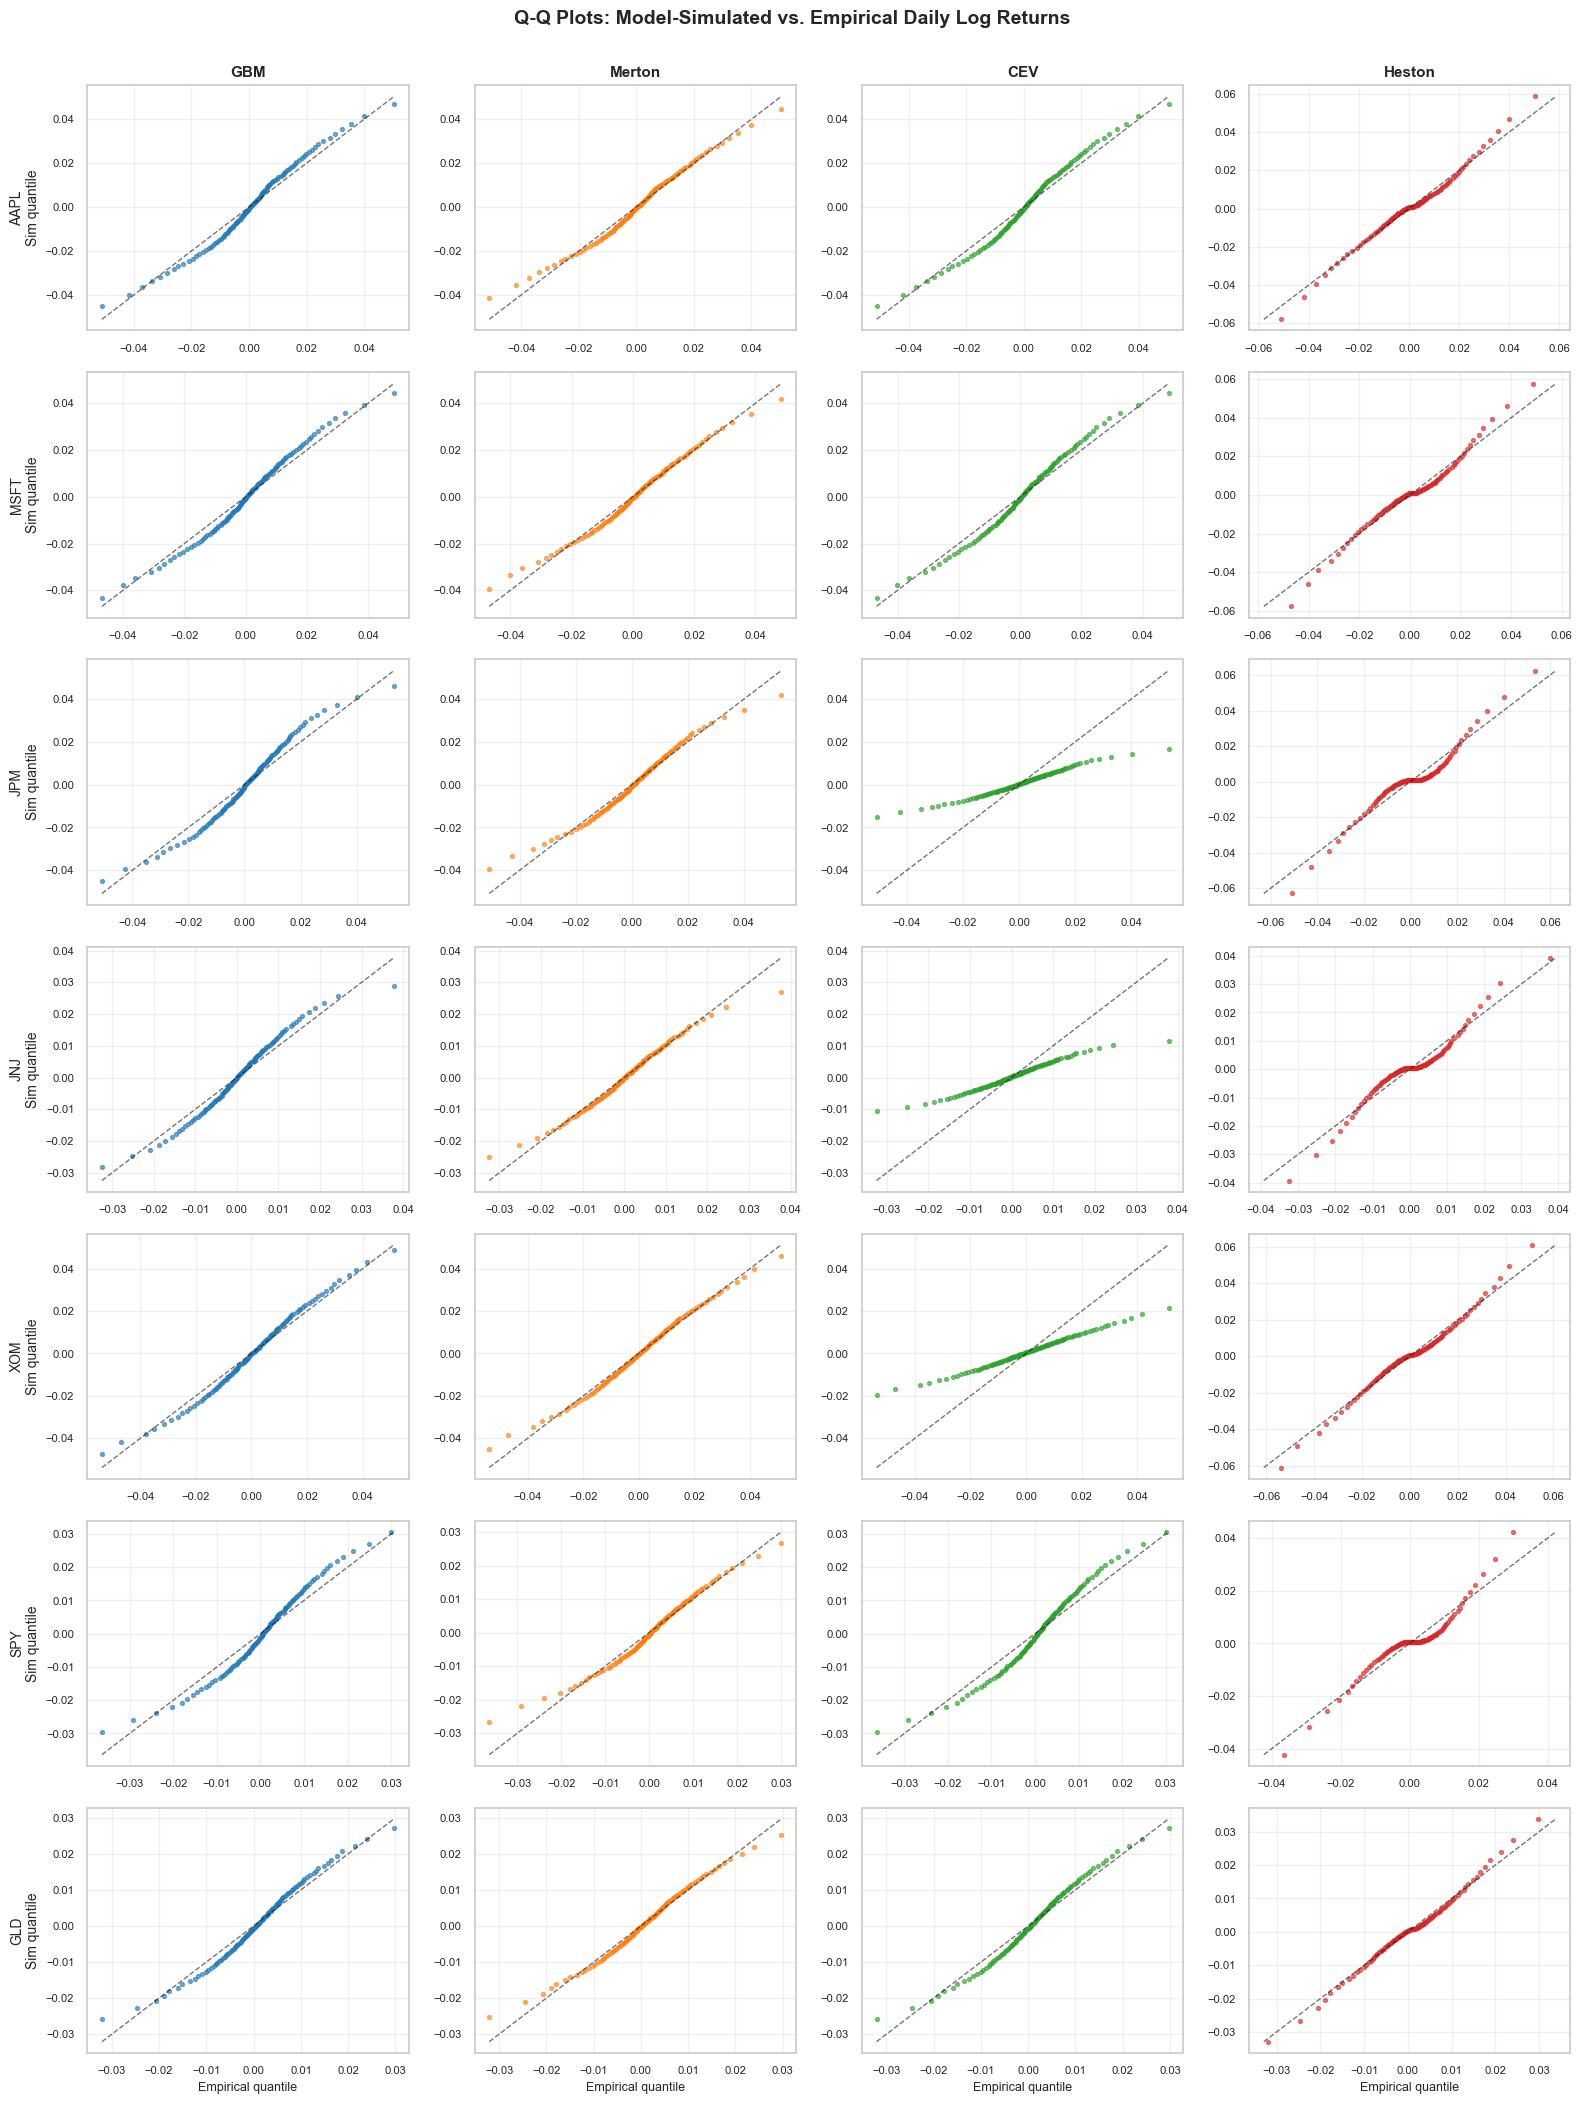

In [9]:
def simulated_daily_returns(ticker: str, model_name: str, n_paths: int = 1000) -> np.ndarray:
    """Simulate paths under the calibrated model and return flattened daily log returns."""
    horizon = len(log_returns)
    s0 = float(prices[ticker].iloc[0])
    params = calibrated[ticker][model_name]

    if model_name == "GBM":
        paths = simulate_gbm(s0, params, horizon, n_paths, TRADING_DAYS, seed=RANDOM_SEED)
    elif model_name == "Merton":
        paths = simulate_merton(s0, params, horizon, n_paths, TRADING_DAYS, seed=RANDOM_SEED)
    elif model_name == "CEV":
        paths = simulate_cev(s0, params, horizon, n_paths, TRADING_DAYS, seed=RANDOM_SEED)
    elif model_name == "Heston":
        paths, _ = simulate_heston(s0, params, horizon, n_paths, TRADING_DAYS, seed=RANDOM_SEED)
    else:
        raise ValueError(f"Unknown model: {model_name}")

    # Convert paths to daily log returns
    log_p = np.log(paths)
    daily_log_rets = np.diff(log_p, axis=1).flatten()
    return daily_log_rets


model_names = ["GBM", "Merton", "CEV", "Heston"]
model_colors = {"GBM": "#1f77b4", "Merton": "#ff7f0e", "CEV": "#2ca02c", "Heston": "#d62728"}

fig, axes = plt.subplots(len(tickers), len(model_names), figsize=(16, 3 * len(tickers)))

for i, ticker in enumerate(tickers):
    empirical = log_returns[ticker].dropna().values
    empirical_q = np.quantile(empirical, np.linspace(0.01, 0.99, 99))

    for j, model_name in enumerate(model_names):
        ax = axes[i, j]
        sim = simulated_daily_returns(ticker, model_name, n_paths=500)
        sim_q = np.quantile(sim, np.linspace(0.01, 0.99, 99))

        ax.scatter(empirical_q, sim_q, s=8, alpha=0.6, color=model_colors[model_name])
        # 45-degree reference line
        lo = min(empirical_q.min(), sim_q.min())
        hi = max(empirical_q.max(), sim_q.max())
        ax.plot([lo, hi], [lo, hi], "k--", linewidth=1, alpha=0.6)

        if i == 0:
            ax.set_title(model_name, fontsize=11, fontweight="bold")
        if j == 0:
            ax.set_ylabel(f"{ticker}\nSim quantile", fontsize=10)
        if i == len(tickers) - 1:
            ax.set_xlabel("Empirical quantile", fontsize=9)
        ax.tick_params(labelsize=8)
        ax.grid(True, alpha=0.3)

fig.suptitle("Q-Q Plots: Model-Simulated vs. Empirical Daily Log Returns", fontsize=14, fontweight="bold", y=1.001)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_qq_plots.png", bbox_inches="tight")
plt.show()

**What to look for in the Q-Q plots:**
- **GBM (blue)** — typically deviates noticeably in the tails for assets with high kurtosis (JPM, SPY). This is the empirical justification for using non-Gaussian models.
- **Merton (orange)** — should track the tails better than GBM, especially the lower tail, due to the explicit jump component.
- **CEV (green)** — captures the leverage effect but still has Gaussian-like tails. Improvement over GBM is asset-dependent.
- **Heston (red)** — captures fat tails through stochastic volatility rather than jumps. Often the best fit for assets with persistent volatility clustering.

The model whose dots lie closest to the diagonal across the entire range is the best fit for that asset. We report findings explicitly in the discussion.

## 7. Goodness-of-Fit Summary

We quantify the Q-Q diagnostic by computing the **mean absolute deviation** between simulated and empirical quantiles. Lower is better.

In [10]:
fit_table = pd.DataFrame(index=tickers, columns=model_names, dtype=float)

for ticker in tickers:
    empirical_q = np.quantile(log_returns[ticker].dropna().values, np.linspace(0.01, 0.99, 99))
    for model_name in model_names:
        sim = simulated_daily_returns(ticker, model_name, n_paths=500)
        sim_q = np.quantile(sim, np.linspace(0.01, 0.99, 99))
        mad = float(np.mean(np.abs(sim_q - empirical_q)))
        fit_table.loc[ticker, model_name] = mad

# Annotate the best (lowest MAD) model per row
best_per_asset = fit_table.idxmin(axis=1)
fit_table["Best fit"] = best_per_asset

print("Mean absolute Q-Q deviation by (asset, model). Lower is better.\n")
fit_table.style.format({m: "{:.5f}" for m in model_names})\
    .background_gradient(cmap="RdYlGn_r", subset=model_names, axis=1)

Mean absolute Q-Q deviation by (asset, model). Lower is better.



,GBM,Merton,CEV,Heston,Best fit
AAPL,0.00282,0.00157,0.00282,0.00158,Merton
MSFT,0.00264,0.00131,0.00264,0.00223,Merton
JPM,0.00363,0.00174,0.00706,0.00354,Merton
JNJ,0.00204,0.00073,0.00419,0.00210,Merton
XOM,0.00230,0.00122,0.00779,0.00189,Merton
SPY,0.00248,0.00109,0.00248,0.00264,Merton
GLD,0.00148,0.00082,0.00148,0.00079,Heston


In [11]:
# Count which model wins for how many assets
winner_counts = best_per_asset.value_counts()
print("Best-fit model frequency across the 7 assets:")
print(winner_counts.to_string())

Best-fit model frequency across the 7 assets:
Merton    6
Heston    1


## 8. Save Calibrated Parameters

We persist all calibrations in a single parquet file so downstream notebooks (Monte Carlo simulation, options overlay) can load them directly without re-fitting.

In [12]:
# Build a long-format DataFrame of all parameters
rows = []
for ticker in tickers:
    for model_name, params in calibrated[ticker].items():
        for field, value in params.__dict__.items():
            rows.append({
                "ticker": ticker,
                "model":  model_name,
                "param":  field,
                "value":  float(value),
            })

params_df = pd.DataFrame(rows)
params_path = PROCESSED_DIR / "calibrated_parameters.parquet"
params_df.to_parquet(params_path)

# Also save the goodness-of-fit table
fit_path = PROCESSED_DIR / "goodness_of_fit.parquet"
fit_table.drop(columns=["Best fit"]).to_parquet(fit_path)

print(f"Saved {params_path.relative_to(PROJECT_ROOT)}  ({params_path.stat().st_size / 1024:.1f} KB)")
print(f"Saved {fit_path.relative_to(PROJECT_ROOT)}  ({fit_path.stat().st_size / 1024:.1f} KB)")
print(f"\nTotal parameter rows: {len(params_df)} (= {len(tickers)} tickers x 4 models x params)")

Saved data/processed/calibrated_parameters.parquet  (4.1 KB)
Saved data/processed/goodness_of_fit.parquet  (3.8 KB)

Total parameter rows: 112 (= 7 tickers x 4 models x params)


## 9. Summary

**What this notebook accomplished:**

1. Fitted four stochastic models — GBM, Merton, CEV, Heston — to each of the seven assets in the universe, producing 28 calibrated parameter sets.
2. Documented each calibration procedure with explicit math: maximum likelihood for GBM, threshold method for Merton, OLS regression for CEV, method of moments on realized variance for Heston.
3. Validated the Heston Feller condition for each asset and flagged any violations.
4. Produced a 7×4 grid of Q-Q plots that visually demonstrates how well each model captures each asset's empirical distribution.
5. Quantified the goodness-of-fit numerically via mean absolute Q-Q deviation, and identified the best-fitting model per asset.

**What this enables for the rest of the project:**

Notebook 04 will use these calibrated parameters to run Monte Carlo simulations of asset prices forward in time under each model. Those simulated price paths will then drive portfolio optimization (Notebook 04 continued) and the option overlay analysis (Notebook 05). The goodness-of-fit results from this notebook directly inform the regime view in Notebook 07.

**Next:** Notebook 04 — Monte Carlo forward simulation under each calibrated model, computing portfolio P&L distributions.